In [1]:
import pyvista as pv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
from io import StringIO
import re

# Read the result files

In [2]:
df1 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-steady_state_M2_0.10_BUMP_500_n.csv")
df2 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-steady_state_SW_M2_0.3_BUMP_500_n.csv")
df1

,time,ekin,epot,work,econ,efri,tot
0,0.000000e+00,0.000063,5.75000,0.000000,0.000000e+00,0.000000,0.000000e+00
1,1.830100e-08,0.000090,5.74997,-0.000002,0.000000e+00,0.000002,-3.126190e-08
2,3.660190e-08,0.000142,5.74992,-0.000030,9.683670e-20,0.000004,2.621600e-05
3,5.490290e-08,0.000219,5.74984,-0.000084,3.558920e-19,0.000005,7.812480e-05
4,7.320380e-08,0.000319,5.74974,-0.000162,7.168150e-19,0.000007,1.546020e-04
...,...,...,...,...,...,...,...
86381,1.580810e-03,0.073915,6.09195,1.380700,2.885520e-11,0.048543,-1.013450e+00
86382,1.580820e-03,0.073944,6.09180,1.380460,2.885530e-11,0.048543,-1.013320e+00
86383,1.580840e-03,0.073974,6.09166,1.380210,2.885550e-11,0.048544,-1.013180e+00
86384,1.580860e-03,0.074004,6.09152,1.379970,2.885560e-11,0.048544,-1.013050e+00


In [3]:
dt = df1["time"][1] - df1["time"][0]
dt

1.8301e-08

In [4]:
reader1.set_active_time_value(0)
mesh = reader1.read()[0]
print(mesh.point_data.keys())
print(mesh.cell_data.keys())
# for t in reader1.time_values:
#     reader1.set_active_time_value(t)
#     mesh = reader1.read()[0]
#     mesh = mesh.clip(
#         normal = (0,-1,0),
#         origin = (0,0,0),
#         invert = False
#     )    
# for t in reader2.time_values:
#     reader2.set_active_time_value(t)
#     mesh = reader2.read()[0]
#     mesh = mesh.clip(
#         normal = (0,-1,0),
#         origin = (0,0,0),
#         invert = False
#     )  

['acceleration', 'blocked_dofs', 'displacement', 'external_force', 'internal_force', 'mass', 'velocity']
[]


In [5]:
## Construct the stress field 
## Note that mesh list is a pointer list so changing any element of the list is easy enough
nu   = 0.33
E    = 7.98e9

from mech_tools import add_plane_stress_energy, total_internal_energy

energies1 = []
energies2 = []

# for t in reader1.time_values:
#     reader1.set_active_time_value(t)
#     mesh = reader1.read()[0]
#     mesh = add_plane_stress_energy(mesh, E, nu)
#     energies1.append(total_internal_energy(mesh))
# for t in reader2.time_values:
#     reader2.set_active_time_value(t)
#     mesh = reader2.read()[0]
#     mesh = add_plane_stress_energy(mesh, E, nu)
#     energies2.append(total_internal_energy(mesh))

# Plotting

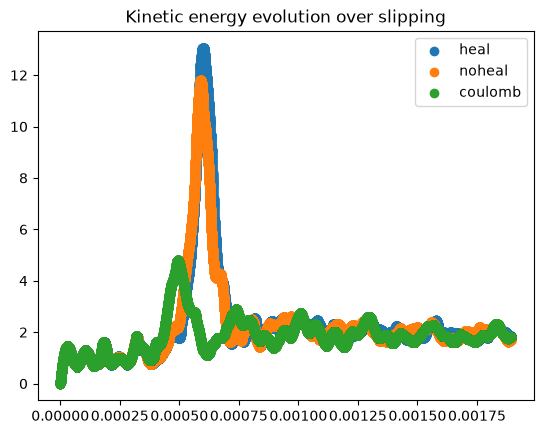

In [2]:
df1 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-SW_noheal_vini_pc_0.3_100_n.csv")
df2 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-SW_noheal_vini_pc_0.3_200_n.csv")
df3 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-SW_noheal_vini_pc_0.3_500_n.csv")
#plt.scatter([t * mult for t in reader1.time_values],energies1,label="Slip weakening")
#plt.scatter([mesh["time"][0]*mult for mesh in meshes3],energies3,label="Slip weakening")
#plt.scatter([t * mult for t in reader2.time_values],energies2,label="Coulomb")
plt.scatter(df1["time"],df1["ekin"],label = "heal")
plt.scatter(df2["time"],df2['ekin'],label = "noheal")
plt.scatter(df3["time"],df3['ekin'],label = "coulomb")
plt.title("Kinetic energy evolution over slipping")
plt.legend()

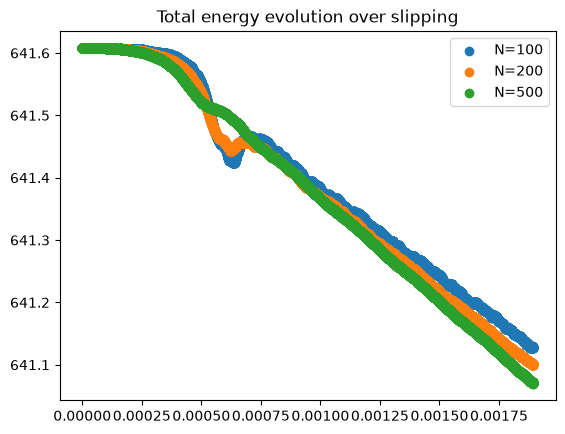

In [3]:
df1 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-SW_noheal_vini_pc_0.3_100_n.csv")
df2 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-SW_noheal_vini_pc_0.3_200_n.csv")
df3 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-SW_noheal_vini_pc_0.3_500_n.csv")
plt.scatter(df1["time"],df1["ekin"] + df1["epot"] - df1["work"] - df1["econ"] + df1["efri"],label = "N=100")
plt.scatter(df2["time"],df2["ekin"] + df2["epot"] - df2["work"] - df2["econ"] + df2["efri"],label = "N=200")
plt.scatter(df3["time"],df3["ekin"] + df3["epot"] - df3["work"] - df3["econ"] + df3["efri"],label = "N=500")
plt.title("Total energy evolution over slipping")
#plt.ylim([0,9])
plt.legend()

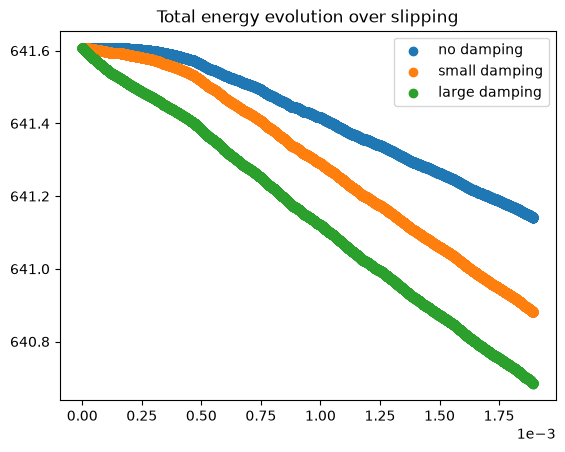

In [6]:
df1 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-Coulomb_new_0.10_200_n.csv")
df2 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-Coulomb_new_0.10_200_s.csv")
df3 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-Coulomb_new_0.10_200_l.csv")
plt.scatter(df1["time"],df1["ekin"] + df1["epot"] - df1["work"] - df1["econ"] + df1["efri"],label = "no damping")
plt.scatter(df2["time"],df2["ekin"] + df2["epot"] - df2["work"] - df2["econ"] + df2["efri"],label = "small damping")
plt.scatter(df3["time"],df3["ekin"] + df3["epot"] - df3["work"] - df3["econ"] + df3["efri"],label = "large damping")
plt.title("Total energy evolution over slipping")
plt.ticklabel_format(axis='x',
                    style='sci',
                    scilimits=(0,0))
#plt.ylim([0,9])
plt.legend()

# Slip-related figures

In [8]:
# Find nodes on the interface 

def split(con_mesh):
    region_ids = np.unique(connected.cell_data["RegionId"])
    
    lower_bodies = []
    upper_bodies = []
    
    for region_id in region_ids:
        body = connected.threshold(
            [region_id, region_id],
            scalars="RegionId",
            preference="cell",
        )

        mean_y = body.points[:, 1].mean()
        if mean_y<0: 
            lower_bodies.append(region_id)
        else:
            upper_bodies.append(region_id)
    lower_block = con_mesh.threshold(
        [lower_bodies[0],lower_bodies[0]],
        scalars = "RegionId",
        preference = "cell"
        )
    upper_block = con_mesh.threshold(
        [upper_bodies[0],upper_bodies[0]],
        scalars = "RegionId",
        preference = "cell"
        )
    for k in lower_bodies[1:]:
        temp = con_mesh.threshold(
            [k,k],
            scalars = "RegionId",
            preference = "cell"
            )
        lower_block = lower_block.merge(temp)
    for k in upper_bodies[1:]:
        temp = con_mesh.threshold(
            [k,k],
            scalars = "RegionId",
            preference = "cell"
            )
        upper_block = upper_block.merge(temp)
    
    lower_points = lower_block.points
    upper_points = upper_block.points
    y_l = lower_points[:, 1]
    y_u = upper_points[:, 1]
    
    y_interface = 0.0
    tol = 1e-8
    
    lower_interface_ids = np.where(np.abs(y_l - y_interface) < tol)[0]
    upper_interface_ids = np.where(np.abs(y_u - y_interface) < tol)[0]
    
    low_interface_points = lower_points[lower_interface_ids]
    up_interface_points = upper_points[upper_interface_ids]
    return lower_interface_ids, upper_interface_ids, lower_block, upper_block

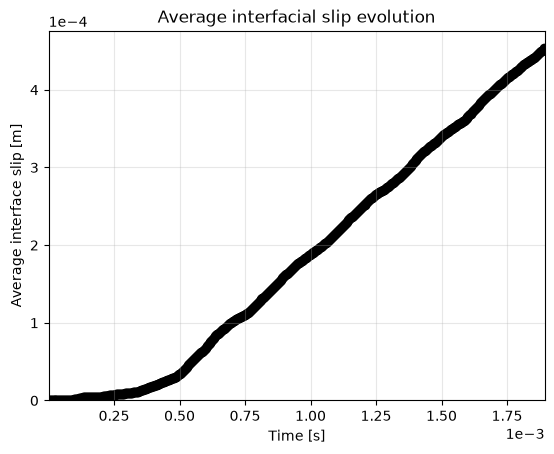

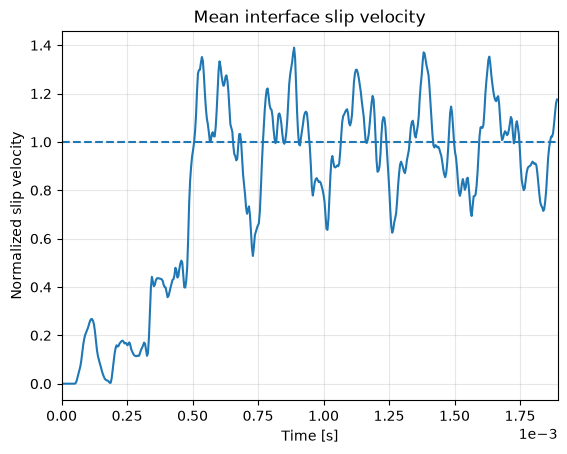

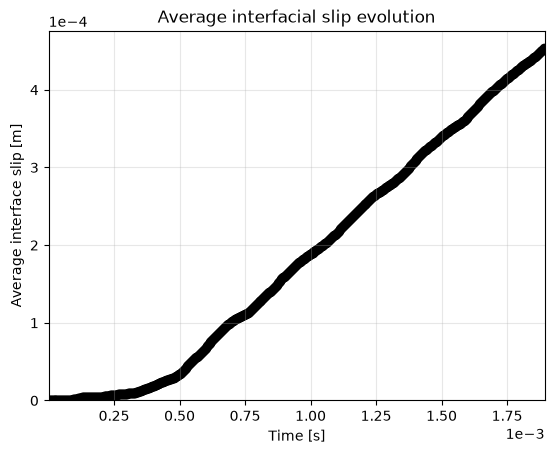

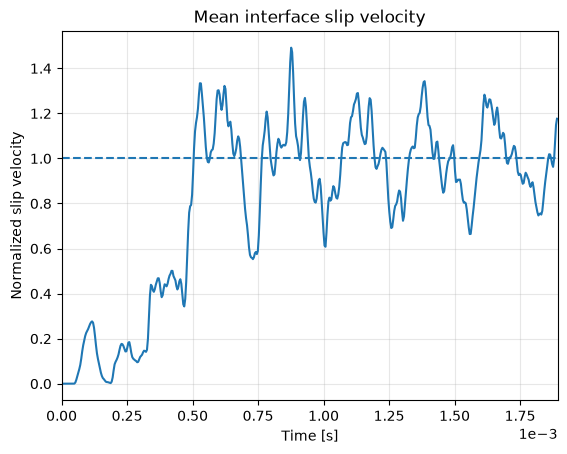

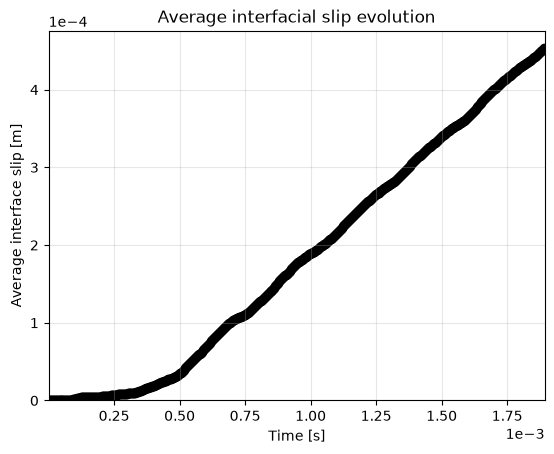

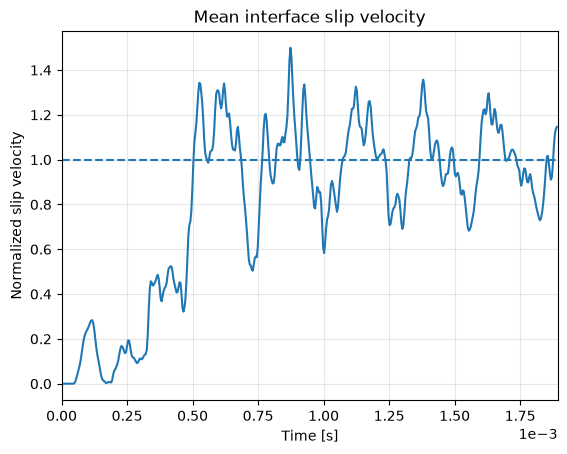

In [18]:
keys = ["Coulomb_new_0.10_100_l", "Coulomb_new_0.10_200_l", "Coulomb_new_0.10_500_l"]
for key in keys:
    file = "/scratch/xyang/build-akantu/build/paraview/" + key + ".pvd"
    df1 = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-"+ key + ".csv")
    t_fin = df1["time"][len(df1["time"])-1]
    reader = pv.get_reader(file)
    ratio = round(t_fin / reader.time_values[-1])
    fig, ax = plt.subplots()
    ax.set_xlim(min(reader.time_values), t_fin)
    ax.set_xlabel("Time [s]")
    ax.ticklabel_format(axis='x',
                    style='sci',
                    scilimits=(0,0))
    ax.ticklabel_format(axis='y',
                    style='sci',
                    scilimits=(0,0))
    ax.set_ylabel("Average interface slip [m]")
    ax.set_title("Average interfacial slip evolution")
    ax.grid(True, alpha=0.3)
    
    for t in reader.time_values:
        reader.set_active_time_value(t)
        mesh = reader.read()[0]
        connected = mesh.connectivity()
        region_ids = np.unique(connected.cell_data["RegionId"])
        low_interface_ids, up_interface_ids, lower_block, upper_block = split(connected)
        top_u = upper_block.point_data["displacement"][up_interface_ids]
        bottom_u = lower_block.point_data["displacement"][low_interface_ids]
        u_tu = top_u[:, 0]
        u_tl = bottom_u[:,0]
        
        x_l = lower_block.points[low_interface_ids][:, 0]
        x_t = upper_block.points[up_interface_ids][:, 0]
        order_l = np.argsort(x_l)
        order_t = np.argsort(x_t)
        u_tl = u_tl[order_l]
        u_tu = u_tu[order_t]
    
        ax.scatter(t*ratio, np.mean(u_tu - u_tl), color = "black")
    ax.set_ylim(0,None)
    fig.savefig("Figs/"+  key + "_averageslip.png", dpi=300, bbox_inches="tight")
    
    
    x = []
    y = []
    
    for scatter in ax.collections:
        xy = scatter.get_offsets()[0]
        x.append(xy[0])
        y.append(xy[1])
    
    x = np.array(x)
    y = np.array(y)
    
    dydx = np.gradient(y, x)
    
    fig2, ax2 = plt.subplots()
    v_ss = 3e-1
    ax2.plot(x, dydx/v_ss)
    ax2.set_xlim(0,t_fin)
    ax2.axhline(1, linestyle = "--")
    ax2.set_xlabel("Time [s]")
    ax2.ticklabel_format(axis='x',
                    style='sci',
                    scilimits=(0,0))
    ax2.set_ylabel("Normalized slip velocity")
    ax2.set_title("Mean interface slip velocity")
    ax2.grid(True, alpha=0.3)
    
    fig2.savefig("Figs/"+  key + "_averageVslip.png", dpi=300, bbox_inches="tight")

Slope:     2.997357e-01
Intercept: -1.116375e-04
Theoretical Intercept: -9.464600e-05


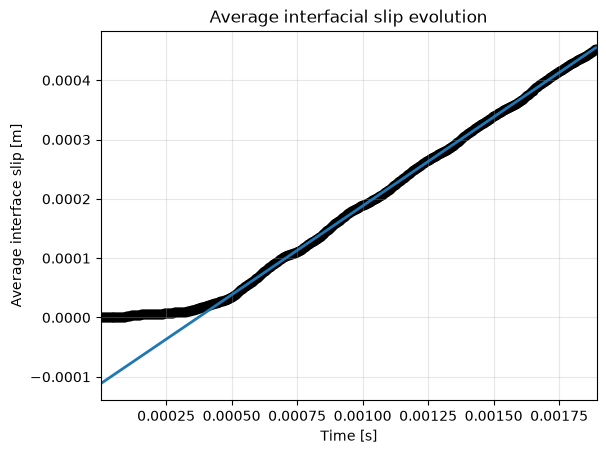

In [17]:
start_index = round(len(reader.time_values)/5*4)
x_half = x[start_index:]
y_half = y[start_index:]
# Linear least-squares fit: y = slope*x + intercept
slope, intercept = np.polyfit(x_half, y_half, deg=1)

y_fit = slope * x + intercept
plt.scatter(x,y, color = "black")
plt.plot(x,y_fit, linewidth = 2, label = "steady state linear fit")
plt.xlim(min(reader.time_values), t_fin)
plt.xlabel("Time [s]")
plt.ylabel("Average interface slip [m]")
plt.title("Average interfacial slip evolution")
plt.grid(True, alpha=0.3)
print(f"Slope:     {slope:.6e}")
print(f"Intercept: {intercept:.6e}")
v0 = 3e-1
t_ramp = t_fin/3
inter_th= v0*t_ramp/2 
print(f"Theoretical Intercept: {-inter_th:.6e}")

# Average friction coefficient

In [31]:
base = "Coulomb_new_0.10_500_n"
fields_file = Path(
    "/scratch/xyang/build-akantu/build/" + base +"_friction_interface.fields"
)
data_dir = fields_file.parent / f"{base}_friction_interface-DataFiles"

def read_blocks(filename):
    """Return one NumPy array per dump time."""
    text = Path(filename).read_text().strip()
    blocks = re.split(r"\n\s*\n", text)
    arrays = []
    for block in blocks:
        data = np.loadtxt(StringIO(block))
        arrays.append(np.atleast_2d(data))
    return arrays

# Read every MPI-rank piece of a field
def read_field(field_name):
    files = sorted(data_dir.glob(f"{base}_friction_interface_{field_name}.proc*.out"))
    if not files:  # Serial dumps have no .proc<rank> suffix.
        files = [data_dir / f"{base}_friction_interface_{field_name}.out"]
    return [read_blocks(f) for f in files]

# Fields at every time step, concatenated across ranks
position_by_rank = read_field("position")
tau_by_rank = read_field("friction_traction")
normal_by_rank = read_field("contact_pressure")

# step = 400
# xy = np.concatenate([a[step] for a in position_by_rank])
# tau = np.concatenate([a[step] for a in tau_by_rank])
# traction_n = np.concatenate([a[step] for a in normal_by_rank])

# # Your interface is horizontal, so the x component is the shear traction.
# order = np.argsort(xy[:, 0])
# plt.plot(xy[order, 0], tau[order, 0])
# plt.xlabel("x")
# plt.xlim(0,0.5)
# plt.ylabel("shear traction")
# plt.show()

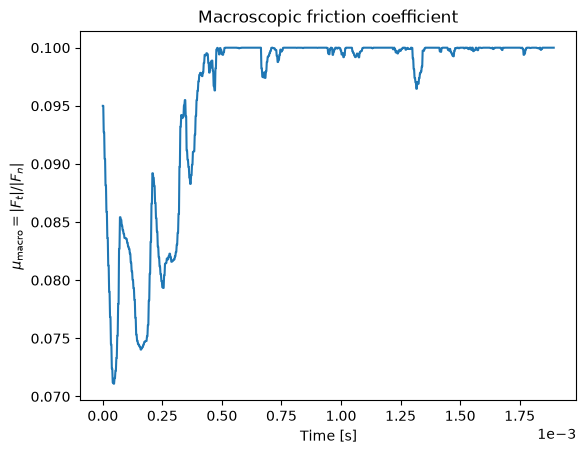

In [32]:
# Integrate the signed contact tractions along the horizontal interface.
# The dumped fields are tractions, so the integrals are forces per unit
# out-of-plane thickness.  Duplicate interface nodes at MPI partition
# boundaries are removed before the trapezoidal integration.

x_mid = 0.25                 # or 0.5 * (x.min() + x.max())
precrack_length = 0.5 / 20   # L / 20 for L = 0.5
half_pc = 0.5 * precrack_length

def integrate_outside_weak_zone(values):
    return (
        np.trapz(values[left], x[left])
        + np.trapz(values[right], x[right])
    )

def contact_resultant(step, x_mid=None, weak_half_length=0.0):
    xy = np.concatenate([rank[step] for rank in position_by_rank])
    tau = np.concatenate([rank[step] for rank in tau_by_rank])
    pressure = np.concatenate([rank[step] for rank in normal_by_rank])

    order = np.argsort(xy[:, 0])
    x = xy[order, 0]
    tau_x = tau[order, 0]
    pressure_y = pressure[order, 1]

    _, unique = np.unique(x, return_index=True)
    x, tau_x, pressure_y = x[unique], tau_x[unique], pressure_y[unique]

    if weak_half_length == 0.0:
        return np.trapz(tau_x, x), np.trapz(pressure_y, x)

    left = x < x_mid - weak_half_length
    right = x > x_mid + weak_half_length

    shear_force = (
        np.trapz(tau_x[left], x[left])
        + np.trapz(tau_x[right], x[right])
    )
    normal_force = (
        np.trapz(pressure_y[left], x[left])
        + np.trapz(pressure_y[right], x[right])
    )
    return shear_force, normal_force

n_steps = min(len(rank) for rank in position_by_rank)
resultants = np.array([contact_resultant(step) for step in range(n_steps)])
shear_force, normal_force = resultants.T
mu_macro = abs(shear_force) / abs(normal_force)
df = pd.read_csv("/scratch/xyang/build-akantu/build/friction-energies-"+base+".csv")
reference_times = df["time"]

# Approximate mapping: assumes contact fields were dumped uniformly in solver steps.
dump_indices = np.linspace(0, len(reference_times) - 1, n_steps)
times = np.interp(
    dump_indices,
    np.arange(len(reference_times)),
    reference_times,
)

macroscopic_friction = pd.DataFrame({
    "time": times,
    "shear_force": shear_force,
    "normal_force": normal_force,
    "mu_macro": mu_macro,
})

ax = macroscopic_friction.plot(x="time", y="mu_macro", legend=False)
ax.set_ylabel(r"$\mu_{\mathrm{macro}} = |F_t| / |F_n|$")
ax.set_xlabel("Time [s]")
ax.ticklabel_format(axis='x',
                    style='sci',
                    scilimits=(0,0))
ax.set_title("Macroscopic friction coefficient")
plt.show()

# Export to video files

501
Saving interface_sync_SW_noheal_vini_pc_0.3_500_n.mp4...
Done.
201
Saving interface_sync_SW_noheal_vini_pc_0.3_200_n.mp4...
Done.


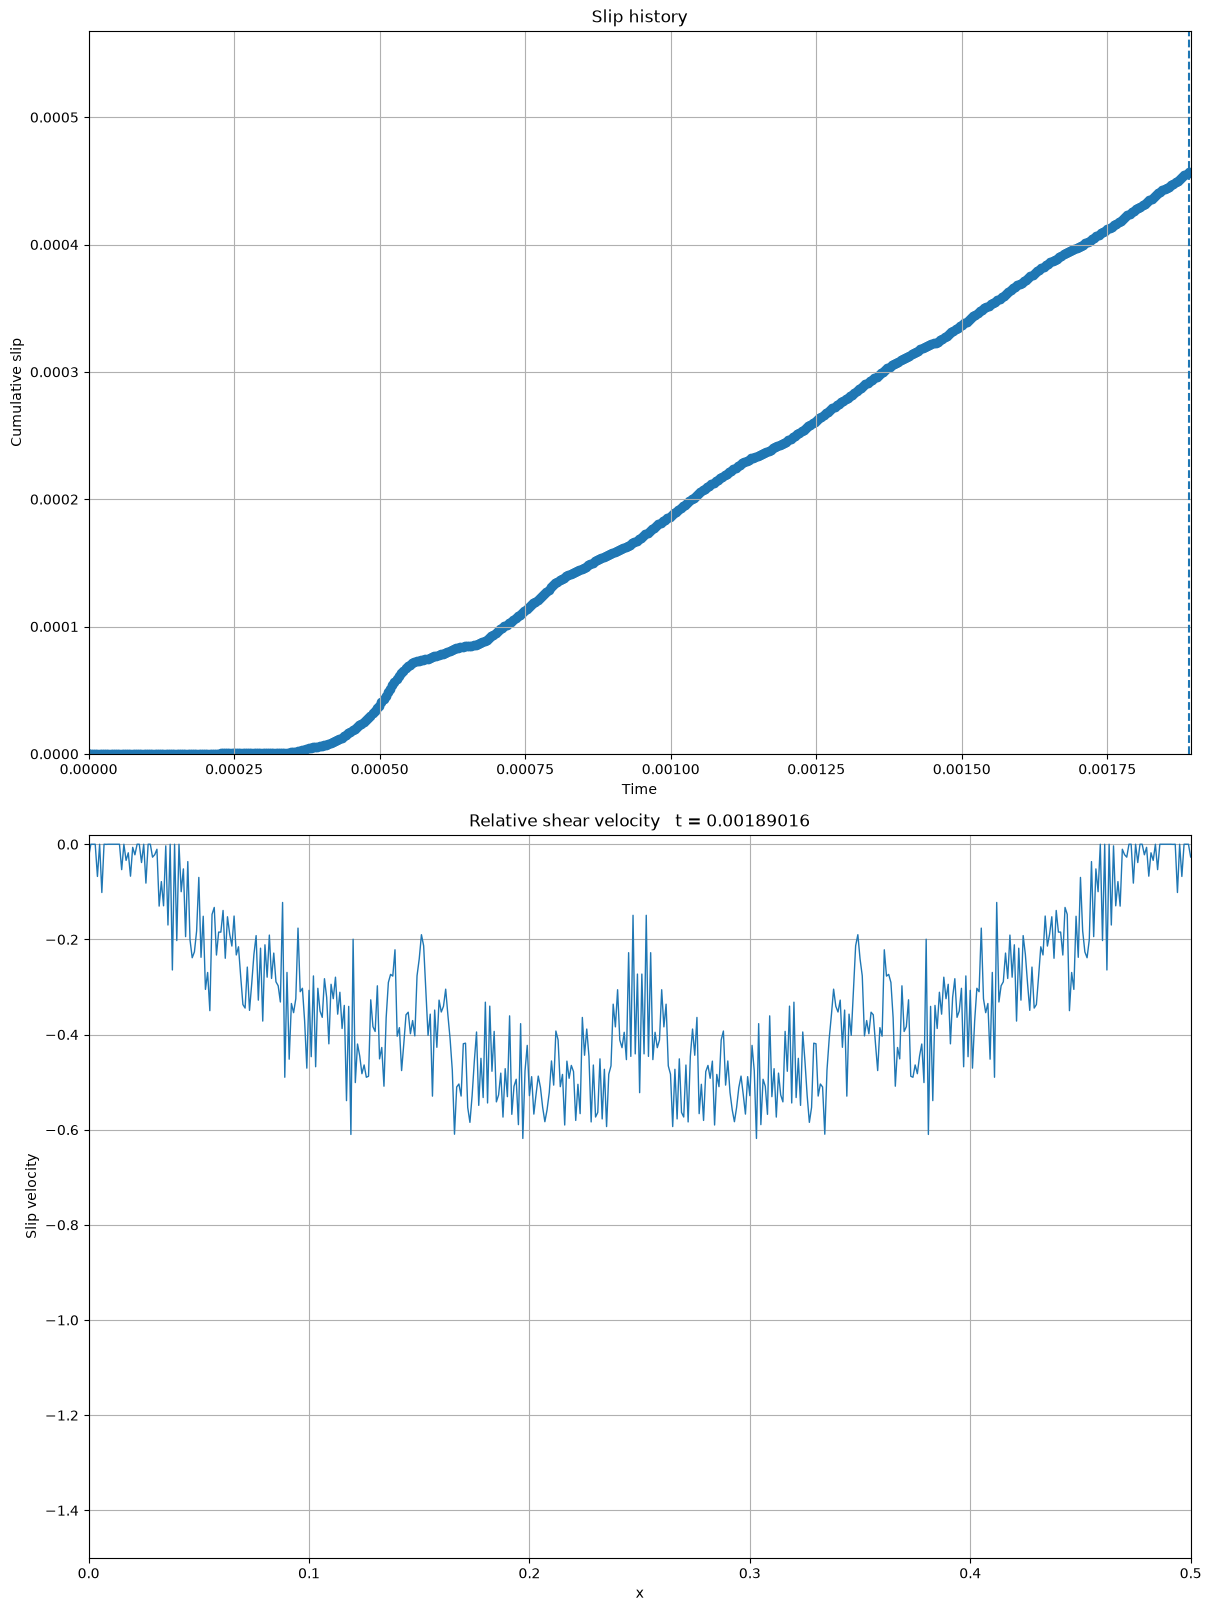

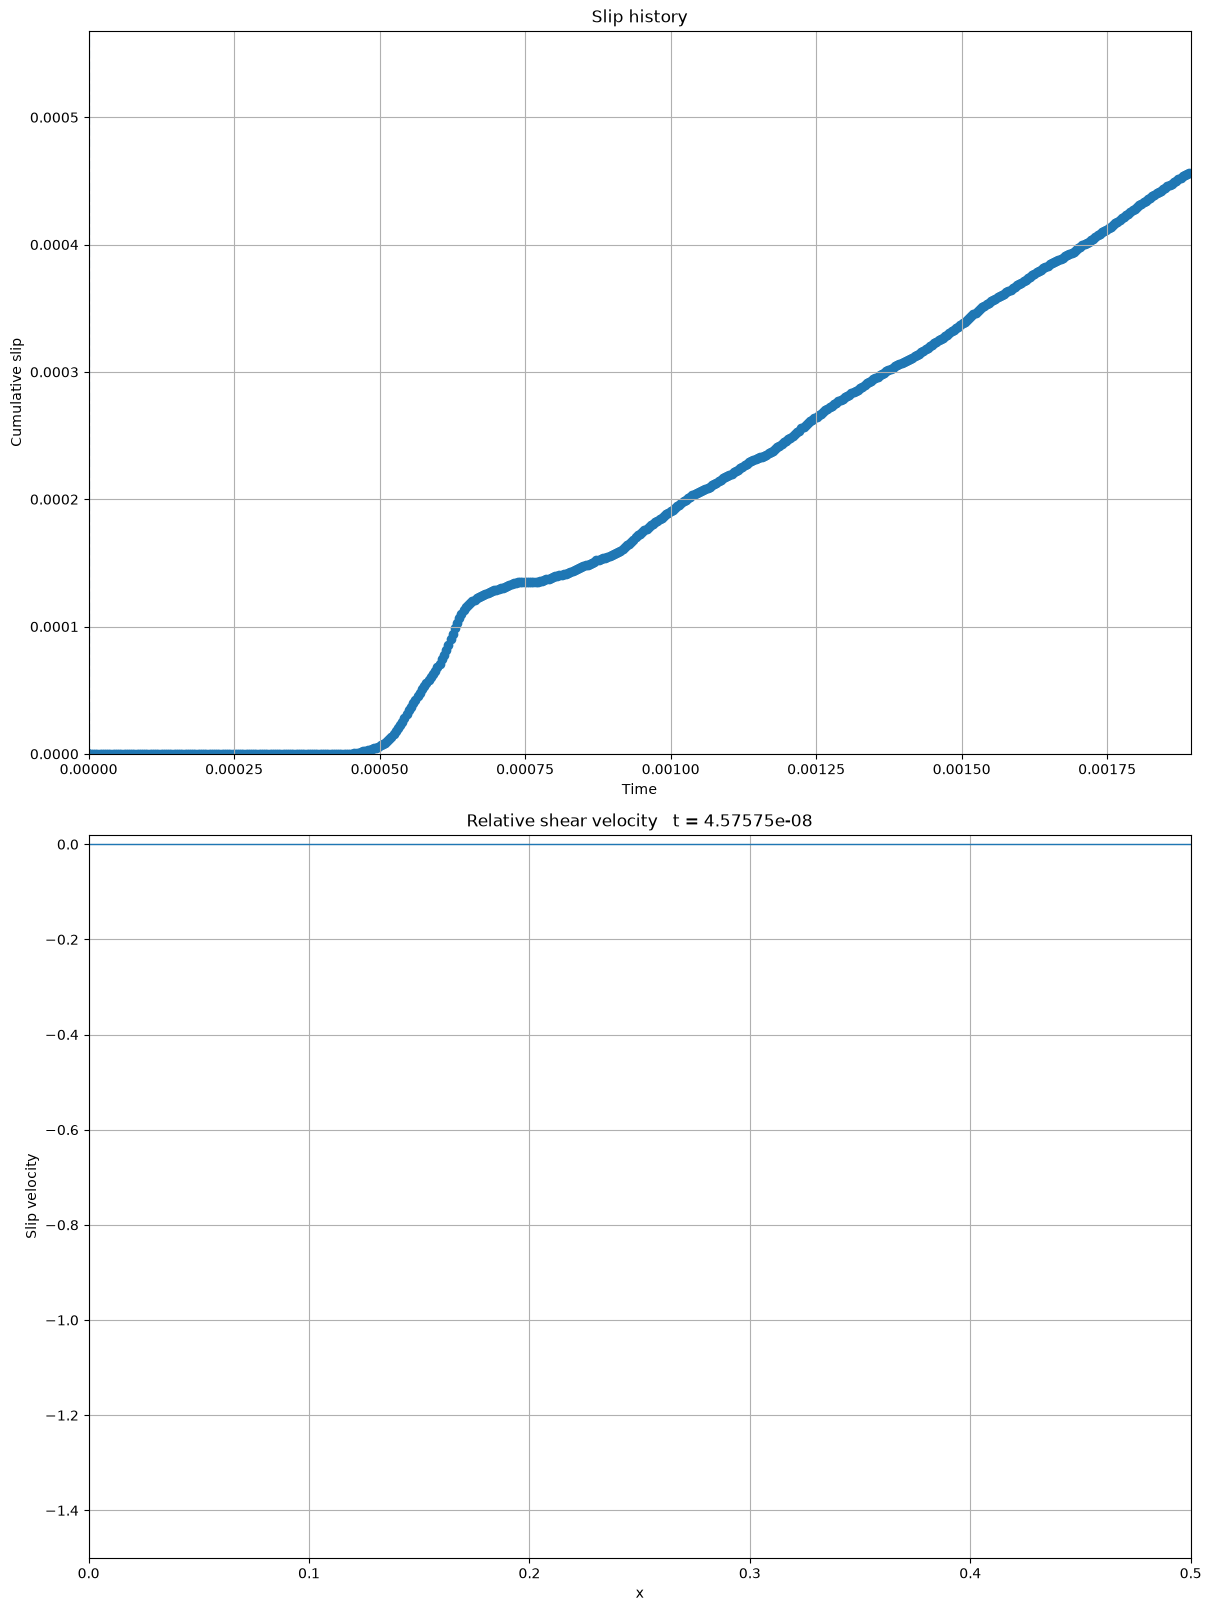

In [34]:
import interface_trac
import interface_v_a_ave
import bottom_v
import importlib
importlib.reload(interface_v_a_ave)

for f in [
    "SW_noheal_vini_pc_0.3_500_n", "SW_noheal_vini_pc_0.3_200_n"
]:
    interface_v_a_ave.main(f,3e-1)
    #bottom_v.main(f)

# Slip Front speed

In [35]:
# Detect the right-moving first front from the relative tangential velocity.
# `slip_threshold_fraction` can be raised if small-amplitude numerical noise is detected.
slip_threshold_fraction = 0.05
front_direction = "right"  # Use "left" for a left-moving front.
front_stop_position = 0.5  # Stop once the right-moving front reaches this boundary.
interface_y = 0.0
interface_tolerance = 1e-8
reader = pv.get_reader("/scratch/xyang/build-akantu/build/friction-energies-"+base+".csv"")

def interface_slip_velocity(mesh):
    """Return sorted x coordinates and relative x velocity at y = interface_y."""
    connected = mesh.connectivity()
    region_ids = np.unique(connected.cell_data["RegionId"])
    lower_bodies, upper_bodies = [], []

    for region_id in region_ids:
        body = connected.threshold(
            [region_id, region_id], scalars="RegionId", preference="cell"
        )
        (lower_bodies if body.points[:, 1].mean() < interface_y else upper_bodies).append(body)

    if not lower_bodies or not upper_bodies:
        raise ValueError("Could not identify bodies on both sides of the interface.")

    lower_block = lower_bodies[0]
    upper_block = upper_bodies[0]
    for body in lower_bodies[1:]:
        lower_block = lower_block.merge(body)
    for body in upper_bodies[1:]:
        upper_block = upper_block.merge(body)

    lower_ids = np.flatnonzero(np.abs(lower_block.points[:, 1] - interface_y) < interface_tolerance)
    upper_ids = np.flatnonzero(np.abs(upper_block.points[:, 1] - interface_y) < interface_tolerance)
    lower_x = lower_block.points[lower_ids, 0]
    upper_x = upper_block.points[upper_ids, 0]
    lower_order, upper_order = np.argsort(lower_x), np.argsort(upper_x)
    lower_x, upper_x = lower_x[lower_order], upper_x[upper_order]

    if lower_x.shape != upper_x.shape or not np.allclose(lower_x, upper_x):
        raise ValueError("Upper and lower interface nodes do not align in x.")

    lower_vx = lower_block.point_data["velocity"][lower_ids, 0][lower_order]
    upper_vx = upper_block.point_data["velocity"][upper_ids, 0][upper_order]
    return lower_x, lower_vx - upper_vx

times = np.asarray(reader.time_values)
profiles = []
for time in times:
    reader.set_active_time_value(time)
    profiles.append(interface_slip_velocity(reader.read()[0]))

peak_slip_velocity = max(np.abs(slip_velocity).max() for _, slip_velocity in profiles)
slip_threshold = slip_threshold_fraction * peak_slip_velocity
front_time, front_position = [], []

for time, (x, slip_velocity) in zip(times, profiles):
    active = np.abs(slip_velocity) >= slip_threshold
    if active.any():
        position = x[active].max() if front_direction == "right" else x[active].min()
        front_time.append(time)
        front_position.append(position)
        if ((front_direction == "right" and position >= front_stop_position) or
                (front_direction == "left" and position <= front_stop_position)):
            break

front_time = np.asarray(front_time)
front_position = np.asarray(front_position)
fit_mask = np.ones(front_time.size, dtype=bool)

if fit_mask.sum() < 2:
    raise RuntimeError("Too few front positions before reaching the stop boundary.")

front_speed, intercept = np.polyfit(front_time[fit_mask], front_position[fit_mask], 1)
print(f"First {front_direction}-moving wave-front speed: {front_speed:.6e}")
print(f"Detection threshold: {slip_threshold:.6e} (relative interface velocity)")

fig, ax = plt.subplots()
ax.plot(front_time, front_position, "o", label="detected front")
ax.plot(front_time[fit_mask], front_speed * front_time[fit_mask] + intercept,
        label=f"linear fit: {front_speed:.3e}")
ax.set(xlabel="time", ylabel="front position x",
       title="First interface-wave-front trajectory")
ax.grid(True)
ax.legend()
plt.show()


FileNotFoundError: Path 'build/paraview/SW_noheal_vini_0.3_100_n.pvd' is invalid or does not exist.